# Compare Models

In this notebook I want to compare models - in particular I want to scrutinize, why almost all metrics of "non_aug_run" and "copy_author_run" are the same, except that in the latter one the Chamfer Distance is significantly smaller. This makes no sense to me, as Command and Argument Loss are almost the same.

Input: 
- Model 1
- Model 2
- sampel id

Output:
- printed list comapring MSE, Cmd.-Loss, Arg.-Loss, CD or Invalid
- Running scores

Then I can run the entire evaluation script and see in real time how it goes

In [46]:
import sys
import os
import random
import torch
import importlib
import csv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
sys.path.append(os.path.join('..', 'models','Pointnet_Pointnet2_pytorch', 'models'))
sys.path.append("..")
sys.path.append("../code")

from models.DeepCAD.config.configAE import ConfigAE
from models.DeepCAD.trainer.trainerAE import TrainerAE
from dataset import PointCloudEmbeddingSequenceDataset, PointCloudEmbeddingDataset
from models.DeepCAD.cadlib.macro import ALL_COMMANDS, CMD_ARGS_MASK, EOS_IDX, SOL_IDX, EXT_IDX, ARC_IDX
from models.DeepCAD.cadlib.visualize import vec2CADsolid, CADsolid2pc
from models.DeepCAD.utils import read_ply
from scipy.spatial import cKDTree as KDTree



In [7]:
import warnings

# Ignore any warning matching this pattern
warnings.filterwarnings("ignore", message=".* faces have been skipped due to null triangulation")


In [8]:
def inplace_relu(m):
    classname = m.__class__.__name__
    if classname.find('ReLU') != -1:
        m.inplace=True

In [9]:
def load_deepcad(cfg):
    print("Loading DeepCAD: ")
    tr_agent = TrainerAE(cfg)
    tr_agent.load_ckpt(cfg.ckpt)
    tr_agent.net.eval()
    return tr_agent

In [10]:
def infer_pointnet(model, criterion, data, normals=False):
    pc, z_target, vec_target, id = data['pc'], data['z'], data['tgt_vec'], data['id']
    pc = pc.unsqueeze(0)
    if not normals:
        pc = pc[:,:,:3]
    z_target = z_target.unsqueeze(0)
    with torch.no_grad():
        pc = pc.transpose(2, 1)
        z_pred, _ = model(pc)
        loss = criterion(z_pred, z_target)
    return z_pred, loss.item()

In [11]:
def infer_deepcad(model, z_pred, data):
    vec_target = data['tgt_vec']
    z_pred = z_pred.unsqueeze(dim = 1)
    with torch.no_grad():
        output = model.decode(z_pred)
        output["tgt_commands"] = vec_target[:, 0].unsqueeze(0)
        output["tgt_args"] = vec_target[:, 1:].unsqueeze(0)
        loss_dict = model.loss_func(output)
        cmd_loss = loss_dict['loss_cmd'].item()
        arg_loss = loss_dict['loss_args'].item()
        vec_pred = model.logits2vec(output)
        return vec_pred, cmd_loss, arg_loss

In [12]:
def calculate_ACC(results):

    TOLERANCE = 3

    # overall accuracy
    avg_cmd_acc = [] # ACC_cmd
    avg_param_acc = [] # ACC_param
    
    # accuracy w.r.t. each command type
    each_cmd_cnt = np.zeros((len(ALL_COMMANDS),))
    each_cmd_acc = np.zeros((len(ALL_COMMANDS),))

    # accuracy w.r.t each parameter
    args_mask = CMD_ARGS_MASK.astype(np.float32)
    N_ARGS = args_mask.shape[1]
    each_param_cnt = np.zeros([*args_mask.shape])
    each_param_acc = np.zeros([*args_mask.shape])

    B = results["tgt_commands"].shape[0]

    for i in range(B): 
        seq_length = list(results["tgt_commands"][i]).index(EOS_IDX)
        out_cmd = results["pred"][i,:seq_length,0]
        gt_cmd = results["tgt_commands"][i, :seq_length].numpy()
    
        out_param = results["pred"][i,:seq_length,1:]
        gt_param = results["tgt_args"][i, :seq_length].numpy()

        cmd_acc = (out_cmd == gt_cmd).astype(np.int32)
        param_acc = []
              
        for j in range(len(gt_cmd)):
            cmd = gt_cmd[j]
            each_cmd_cnt[cmd] += 1
            each_cmd_acc[cmd] += cmd_acc[j]
            if cmd in [SOL_IDX, EOS_IDX]:
                continue
        
            if out_cmd[j] == gt_cmd[j]: # NOTE: only account param acc for correct cmd
                tole_acc = (np.abs(out_param[j] - gt_param[j]) < TOLERANCE).astype(np.int32)
                if cmd == EXT_IDX:
                    tole_acc[-2:] = (out_param[j] == gt_param[j]).astype(np.int32)[-2:]
                elif cmd == ARC_IDX:
                    tole_acc[3] = (out_param[j] == gt_param[j]).astype(np.int32)[3]
                valid_param_acc = tole_acc[args_mask[cmd].astype(bool)].tolist()
                param_acc.extend(valid_param_acc)
                each_param_cnt[cmd, np.arange(N_ARGS)] += 1
                each_param_acc[cmd, np.arange(N_ARGS)] += tole_acc

        if len(param_acc) == 0: 
            param_acc = 0
        else:
            param_acc = np.mean(param_acc)
        
        avg_param_acc.append(param_acc)
        cmd_acc = np.mean(cmd_acc)
        avg_cmd_acc.append(cmd_acc)

    avg_cmd_acc = np.mean(avg_cmd_acc)
    avg_param_acc = np.mean(avg_param_acc)
    
    each_cmd_acc = each_cmd_acc / (each_cmd_cnt + 1e-6)

    # acc of each parameter type
    each_param_acc = each_param_acc * args_mask
    each_param_cnt = each_param_cnt * args_mask
    each_param_acc = each_param_acc / (each_param_cnt + 1e-6)
    return avg_cmd_acc, avg_param_acc

In [13]:
def calculate_CD(vec_pred, gt_pc_path, vec_target, data_id):

    seq_len = vec_target[:,0].tolist().index(EOS_IDX)
    vec_pred = vec_pred.squeeze()[:seq_len]

    try:
        shape = vec2CADsolid(vec_pred) # out vec only contains until target seq length
    except Exception as e:
        return float('nan') # Create CAD failed
    
    try:
        out_pc = CADsolid2pc(shape, 2000, data_id) # 2000 is the number of sampled points
    except Exception as e:
        return float('nan') # Create PC failed

    if np.max(np.abs(out_pc)) > 2: # normalize out-of-bound data
        out_pc = normalize_pc(out_pc)

    gt_pc = read_ply(gt_pc_path)
    sample_idx = random.sample(list(range(gt_pc.shape[0])), 2000)
    gt_pc = gt_pc[sample_idx]

    cd = chamfer_dist(gt_pc, out_pc)
    return cd


In [14]:
def chamfer_dist(gt_points, gen_points, offset=0, scale=1):
    gen_points = gen_points / scale - offset

    # one direction
    gen_points_kd_tree = KDTree(gen_points)
    one_distances, one_vertex_ids = gen_points_kd_tree.query(gt_points)
    gt_to_gen_chamfer = np.mean(np.square(one_distances))

    # other direction
    gt_points_kd_tree = KDTree(gt_points)
    two_distances, two_vertex_ids = gt_points_kd_tree.query(gen_points)
    gen_to_gt_chamfer = np.mean(np.square(two_distances))

    return gt_to_gen_chamfer + gen_to_gt_chamfer

In [15]:
def normalize_pc(points):
    scale = np.max(np.abs(points))
    points = points / scale
    return points

In [16]:
def print_header():
    print("MSE * 10^-3, ACC * 10^-2, CD * 10^-3")
    print(f"{'i':<4} | {'id':<8} | {'mse1':<6} | {'mse2':<6} | {'cmd_loss1':<10} | {'cmd_loss2':<10} | {'arg_loss1':<10} | {'arg_loss2':<10} | {'cmd_acc1':<8} | {'arg_acc1':<8} | {'cmd_acc2':<8} | {'arg_acc2':<8} | {'cd1':<8} | {'cd2':<8} | {'rs_cd1':<8} | {'rs_cd2':<8}")
    print("-" * 175)


def print_line(data):
    print(
        f"{data['i']:<4} | {data['id']:<8} | {data['mse1']*1e3:6.2f} | {data['mse2']*1e3:6.2f} | "
        f"{data['cmd_loss1']:10.4f} | {data['cmd_loss2']:10.4f} | {data['arg_loss1']:10.4f} | {data['arg_loss2']:10.4f} | "
        f"{data['cmd_acc1']*1e2:8.2f} | {data['arg_acc1']*1e2:8.2f} | {data['cmd_acc2']*1e2:8.2f} | {data['arg_acc2']*1e2:8.2f} | "
        f"{data['cd1']*1e3:8.2f} | {data['cd2']*1e3:8.2f} | {data['rs_cd1']*1e3:8.2f} | {data['rs_cd2']*1e3:8.2f} | "
    )


## Start

In [17]:
pointnet1_path = "../models/trained_models/slow_run_2/best.pth"
pointnet2_path = "../models/trained_models/off_normal_run/best.pth"
github_model = "../models/trained_models/github_model_pn/latest.pth"
cfg = ConfigAE('test', model_path="../data/latent", parse=False)

In [22]:
manual_mapping = {
    "sa1.conv_blocks.0.0.weight": "SA_modules.0.mlps.0.0.weight",
    "sa1.conv_blocks.0.1.weight": "SA_modules.0.mlps.0.3.weight",
    "sa1.conv_blocks.0.2.weight": "SA_modules.0.mlps.0.6.weight",
    "sa1.bn_blocks.0.0.weight": "SA_modules.0.mlps.0.1.weight",
    "sa1.bn_blocks.0.0.bias": "SA_modules.0.mlps.0.1.bias",
    "sa1.bn_blocks.0.0.running_mean": "SA_modules.0.mlps.0.1.running_mean",
    "sa1.bn_blocks.0.0.running_var": "SA_modules.0.mlps.0.1.running_var",
    "sa1.bn_blocks.0.0.num_batches_tracked": "SA_modules.0.mlps.0.1.num_batches_tracked",
    "sa1.bn_blocks.0.1.weight": "SA_modules.0.mlps.0.4.weight",
    "sa1.bn_blocks.0.1.bias": "SA_modules.0.mlps.0.4.bias",
    "sa1.bn_blocks.0.1.running_mean": "SA_modules.0.mlps.0.4.running_mean",
    "sa1.bn_blocks.0.1.running_var": "SA_modules.0.mlps.0.4.running_var",
    "sa1.bn_blocks.0.1.num_batches_tracked": "SA_modules.0.mlps.0.4.num_batches_tracked",
    "sa1.bn_blocks.0.2.weight": "SA_modules.0.mlps.0.7.weight",
    "sa1.bn_blocks.0.2.bias": "SA_modules.0.mlps.0.7.bias",
    "sa1.bn_blocks.0.2.running_mean": "SA_modules.0.mlps.0.7.running_mean",
    "sa1.bn_blocks.0.2.running_var": "SA_modules.0.mlps.0.7.running_var",
    "sa1.bn_blocks.0.2.num_batches_tracked": "SA_modules.0.mlps.0.7.num_batches_tracked",
    "sa2.conv_blocks.0.0.weight": "SA_modules.1.mlps.0.0.weight",
    "sa2.conv_blocks.0.1.weight": "SA_modules.1.mlps.0.3.weight",
    "sa2.conv_blocks.0.2.weight": "SA_modules.1.mlps.0.6.weight",
    "sa2.bn_blocks.0.0.weight": "SA_modules.1.mlps.0.1.weight",
    "sa2.bn_blocks.0.0.bias": "SA_modules.1.mlps.0.1.bias",
    "sa2.bn_blocks.0.0.running_mean": "SA_modules.1.mlps.0.1.running_mean",
    "sa2.bn_blocks.0.0.running_var": "SA_modules.1.mlps.0.1.running_var",
    "sa2.bn_blocks.0.0.num_batches_tracked": "SA_modules.1.mlps.0.1.num_batches_tracked",
    "sa2.bn_blocks.0.1.weight": "SA_modules.1.mlps.0.4.weight",
    "sa2.bn_blocks.0.1.bias": "SA_modules.1.mlps.0.4.bias",
    "sa2.bn_blocks.0.1.running_mean": "SA_modules.1.mlps.0.4.running_mean",
    "sa2.bn_blocks.0.1.running_var": "SA_modules.1.mlps.0.4.running_var",
    "sa2.bn_blocks.0.1.num_batches_tracked": "SA_modules.1.mlps.0.4.num_batches_tracked",
    "sa2.bn_blocks.0.2.weight": "SA_modules.1.mlps.0.7.weight",
    "sa2.bn_blocks.0.2.bias": "SA_modules.1.mlps.0.7.bias",
    "sa2.bn_blocks.0.2.running_mean": "SA_modules.1.mlps.0.7.running_mean",
    "sa2.bn_blocks.0.2.running_var": "SA_modules.1.mlps.0.7.running_var",
    "sa2.bn_blocks.0.2.num_batches_tracked": "SA_modules.1.mlps.0.7.num_batches_tracked",
    "sa3.conv_blocks.0.0.weight": "SA_modules.2.mlps.0.0.weight",
    "sa3.conv_blocks.0.1.weight": "SA_modules.2.mlps.0.3.weight",
    "sa3.conv_blocks.0.2.weight": "SA_modules.2.mlps.0.6.weight",
    "sa3.bn_blocks.0.0.weight": "SA_modules.2.mlps.0.1.weight",
    "sa3.bn_blocks.0.0.bias": "SA_modules.2.mlps.0.1.bias",
    "sa3.bn_blocks.0.0.running_mean": "SA_modules.2.mlps.0.1.running_mean",
    "sa3.bn_blocks.0.0.running_var": "SA_modules.2.mlps.0.1.running_var",
    "sa3.bn_blocks.0.0.num_batches_tracked": "SA_modules.2.mlps.0.1.num_batches_tracked",
    "sa3.bn_blocks.0.1.weight": "SA_modules.2.mlps.0.4.weight",
    "sa3.bn_blocks.0.1.bias": "SA_modules.2.mlps.0.4.bias",
    "sa3.bn_blocks.0.1.running_mean": "SA_modules.2.mlps.0.4.running_mean",
    "sa3.bn_blocks.0.1.running_var": "SA_modules.2.mlps.0.4.running_var",
    "sa3.bn_blocks.0.1.num_batches_tracked": "SA_modules.2.mlps.0.4.num_batches_tracked",
    "sa3.bn_blocks.0.2.weight": "SA_modules.2.mlps.0.7.weight",
    "sa3.bn_blocks.0.2.bias": "SA_modules.2.mlps.0.7.bias",
    "sa3.bn_blocks.0.2.running_mean": "SA_modules.2.mlps.0.7.running_mean",
    "sa3.bn_blocks.0.2.running_var": "SA_modules.2.mlps.0.7.running_var",
    "sa3.bn_blocks.0.2.num_batches_tracked": "SA_modules.2.mlps.0.7.num_batches_tracked",
    "sa4.mlp_convs.0.weight": "SA_modules.3.mlps.0.0.weight",
    "sa4.mlp_convs.1.weight": "SA_modules.3.mlps.0.3.weight",
    "sa4.mlp_convs.2.weight": "SA_modules.3.mlps.0.6.weight",
    "sa4.mlp_bns.0.weight": "SA_modules.3.mlps.0.1.weight",
    "sa4.mlp_bns.0.bias": "SA_modules.3.mlps.0.1.bias",
    "sa4.mlp_bns.0.running_mean": "SA_modules.3.mlps.0.1.running_mean",
    "sa4.mlp_bns.0.running_var": "SA_modules.3.mlps.0.1.running_var",
    "sa4.mlp_bns.0.num_batches_tracked": "SA_modules.3.mlps.0.1.num_batches_tracked",
    "sa4.mlp_bns.1.weight": "SA_modules.3.mlps.0.4.weight",
    "sa4.mlp_bns.1.bias": "SA_modules.3.mlps.0.4.bias",
    "sa4.mlp_bns.1.running_mean": "SA_modules.3.mlps.0.4.running_mean",
    "sa4.mlp_bns.1.running_var": "SA_modules.3.mlps.0.4.running_var",
    "sa4.mlp_bns.1.num_batches_tracked": "SA_modules.3.mlps.0.4.num_batches_tracked",
    "sa4.mlp_bns.2.weight": "SA_modules.3.mlps.0.7.weight",
    "sa4.mlp_bns.2.bias": "SA_modules.3.mlps.0.7.bias",
    "sa4.mlp_bns.2.running_mean": "SA_modules.3.mlps.0.7.running_mean",
    "sa4.mlp_bns.2.running_var": "SA_modules.3.mlps.0.7.running_var",
    "sa4.mlp_bns.2.num_batches_tracked": "SA_modules.3.mlps.0.7.num_batches_tracked",
    "fc1.weight": "fc_layer.0.weight",
    "fc1.bias": "fc_layer.0.bias",
    "fc2.weight": "fc_layer.2.weight",
    "fc2.bias": "fc_layer.2.bias",
    "fc3.weight": "fc_layer.4.weight",
    "fc3.bias": "fc_layer.4.bias"
}

In [23]:
def load_pointnet(model_path):

    # Get torch model dir
    model_dir = torch.load(model_path, map_location=torch.device('cpu'), weights_only=True)
    config = model_dir['config']
    print(f"Loading PointNet++ from {os.path.abspath(model_path)}:")
    for key, value in config.items():
        print(f"{key}: {value}")
    print("")

    # Create model
    model = importlib.import_module(config['model_type'])
    normal_channel = False
    if "normals" in config.keys():
        if config["normals"] == True:
            normal_channel = True
    if 'architecture' in config:
        if config['architecture'] == 'own':
            classifier = model.get_model(256, normal_channel=normal_channel)
        elif config['architecture'] == "copy_author":
            classifier = model.get_model_copy_author(256, normal_channel=normal_channel)
        elif config['architecture'] == "tanh":
            classifier = model.get_model_tanh(256, normal_channel=normal_channel)
    else:
        classifier = model.get_model(256, normal_channel=False)
    criterion = model.get_loss_mse()
    classifier.apply(inplace_relu) 
    
    # Load pre-trained model
    state_dict = model_dir['model_state_dict']
    if 'module.' in next(iter(state_dict)):
        state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    classifier.eval()
    classifier.load_state_dict(state_dict)
    
    return classifier, criterion

In [24]:
def load_github_pointnet(model_path):

    # Get torch model dir
    model_dir = torch.load(model_path, map_location=torch.device('cpu'), weights_only=True)


    # Create model
    model = importlib.import_module("pointnet2_cls_msg")
    normal_channel = True
    classifier = model.get_model_copy_author(256, normal_channel=normal_channel)
    criterion = model.get_loss_mse()
    classifier.apply(inplace_relu) 
    
    # Load pre-trained model
    state_dict = model_dir['model_state_dict']
    mapped_state_dict = {
        key1: state_dict[key2] for key1, key2 in manual_mapping.items()
    }
    classifier.eval()
    classifier.load_state_dict(mapped_state_dict)
    
    return classifier, criterion

In [25]:
pointnet1, criterion1 = load_pointnet(pointnet2_path)
pointnet2, criterion2 = load_github_pointnet(github_model)
deepcad = load_deepcad(cfg)

Loading PointNet++ from /Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/models/trained_models/off_normal_run/best.pth:
learning_rate: 0.0001
batch_size: 384
max_epochs: 1000
optimizer: Adam
model_type: pointnet2_cls_msg
save_interval: 50
early_stopping: 50
start_time: 2025-04-11_12-16-07
lr_type: step_adv
msg: True
augmentation: False
gpu: True
architecture: copy_author
normals: True
final_epoch: 990
training_time_min: 8117.24

Loading DeepCAD: 
Loading checkpoint from /Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/data/latent/pretrained/model/ckpt_epoch1000.pth ...


In [26]:
start = True
csv_name = "off_norm_run_vs_github_model_fixed.csv"
if start:
    dataset = PointCloudEmbeddingSequenceDataset("../data", 'test', use_normals=True)
    fieldnames = [
        'i', 'id', 'mse1', 'mse2', 
        'cmd_loss1', 'cmd_loss2', 'arg_loss1', 'arg_loss2',
        'cmd_acc1', 'arg_acc1', 'cmd_acc2', 'arg_acc2', 
        'cd1', 'cd2', 'rs_cd1', 'rs_cd2'
    ]
    col_width = print_header()
    with open(os.path.join('experiments', csv_name), 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
    
    for i, data in enumerate(dataset):
        
        # Infer PointNets
        z_pred1, mse1 = infer_pointnet(pointnet1, criterion1, data, normals=True)
        z_pred2, mse2 = infer_pointnet(pointnet2, criterion2, data, normals=True)
    
        # Infer DeepCAD
        vec_pred1, cmd_loss1, arg_loss1 = infer_deepcad(deepcad, z_pred1, data)
        vec_pred2, cmd_loss2, arg_loss2 = infer_deepcad(deepcad, z_pred2, data)
    
        # Calculate Accuracy
        cmd_acc1, arg_acc1 = calculate_ACC({"tgt_commands": data['tgt_vec'].unsqueeze(0)[:,:,0], "tgt_args": data['tgt_vec'].unsqueeze(0)[:,:,1:], "pred": vec_pred1})
        cmd_acc2, arg_acc2 = calculate_ACC({"tgt_commands": data['tgt_vec'].unsqueeze(0)[:,:,0], "tgt_args": data['tgt_vec'].unsqueeze(0)[:,:,1:], "pred": vec_pred2})

        cd1 = calculate_CD(vec_pred1, dataset.get_pc_path(i), data['tgt_vec'], data['id'])
        cd2 = calculate_CD(vec_pred2, dataset.get_pc_path(i), data['tgt_vec'], data['id'])
    
        existing_cd1 = []
        existing_cd2 = []
        with open(os.path.join('experiments', csv_name), 'r') as file:
            reader = csv.DictReader(file)
            for row in reader:
                if row['cd1'] != 'nan': 
                    existing_cd1.append(float(row['cd1']))
                if row['cd2'] != 'nan':
                    existing_cd2.append(float(row['cd2']))
        
        # Compute running medians (handle NaNs)
        rs_cd1 = np.nanmedian(existing_cd1 + [cd1])
        rs_cd2 = np.nanmedian(existing_cd2 + [cd2])
        metrics_dict = {
                'i': i,
                'id': data['id'],
                'mse1': mse1,
                'mse2': mse2,
                'cmd_loss1': cmd_loss1,
                'cmd_loss2': cmd_loss2,
                'arg_loss1': arg_loss1,
                'arg_loss2': arg_loss2,
                'cmd_acc1': cmd_acc1,
                'arg_acc1': arg_acc1,
                'cmd_acc2': cmd_acc2,
                'arg_acc2': arg_acc2,
                'cd1': cd1,
                'cd2': cd2,
                'rs_cd1': rs_cd1,
                'rs_cd2': rs_cd2
            }
        with open(os.path.join('experiments', csv_name), 'a', newline='') as file:
            writer = csv.DictWriter(file, fieldnames=fieldnames)
            writer.writerow(metrics_dict)
            
        print_line(metrics_dict)





MSE * 10^-3, ACC * 10^-2, CD * 10^-3
i    | id       | mse1   | mse2   | cmd_loss1  | cmd_loss2  | arg_loss1  | arg_loss2  | cmd_acc1 | arg_acc1 | cmd_acc2 | arg_acc2 | cd1      | cd2      | rs_cd1   | rs_cd2  
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


/var/folders/97/07fn6f7n48j71zk65dskp3gm0000gn/T/ipykernel_32808/1991957885.py:45: RuntimeWarning: All-NaN slice encountered
  rs_cd2 = np.nanmedian(existing_cd2 + [cd2])


0    | 00250456 |   6.70 |  71.25 |     0.0000 |     8.8035 |     0.0000 |     2.3411 |   100.00 |   100.00 |    83.33 |   100.00 |     4.18 |      nan |     4.18 |      nan | 
1    | 00440420 |  90.18 | 119.50 |     8.6042 |    10.1155 |    16.9268 |    33.0363 |    70.00 |    16.67 |    70.00 |     0.00 |     7.51 |   388.16 |     5.85 |   388.16 | 
2    | 00819758 | 102.83 | 129.08 |    10.6242 |    11.9616 |    11.0656 |    24.8219 |    42.86 |    25.00 |    42.86 |    25.00 |      nan |      nan |     5.85 |   388.16 | 
3    | 00239323 |  64.21 | 108.62 |     0.0000 |    14.0302 |     4.4272 |    10.8442 |   100.00 |    58.62 |    30.00 |    50.00 |    46.53 |   423.62 |     7.51 |   405.89 | 
4    | 00420729 |  61.96 | 117.09 |     0.0000 |     8.2200 |     5.1988 |     9.4370 |   100.00 |    84.21 |    83.33 |    62.50 |    81.36 |      nan |    27.02 |   405.89 | 
5    | 00646280 | 118.95 | 121.01 |    18.2709 |     7.9900 |    20.7392 |    17.9999 |    16.67 |    33.33 |    45

## Show the results

In [17]:
import pandas as pd
df = pd.read_csv('experiments/slow_run_2vsoff_normal_run.csv')
id = df['id']

In [18]:
def create_comparison_table(row):
    metrics = ["mse", "cmd_loss", "arg_loss", "cmd_acc", "arg_acc", "cd", "rs_cd"]
    model1_values = [round(row[f"{metric}1"].values[0], 5) for metric in metrics]
    model2_values = [round(row[f"{metric}2"].values[0], 5) for metric in metrics]
    
    comparison_df = pd.DataFrame({
        "Metric": metrics,
        "Model 1": model1_values,
        "Model 2": model2_values
    })

    return comparison_df
    
comparison_id = 716729
row = df.loc[df['id'] == comparison_id]
comparison_table = create_comparison_table(row)
comparison_table

,Metric,Model 1,Model 2
0,mse,0.09856,0.09574
1,cmd_loss,0.34770,0.98990
2,arg_loss,12.98932,12.20760
3,cmd_acc,0.66667,0.66667
4,arg_acc,0.66667,0.53333
5,cd,0.06802,0.00938
6,rs_cd,0.00843,0.00894


In [19]:
avg_acc_cmd1 = round(np.mean(df['cmd_acc1']) * 1e2, 2)
avg_acc_arg1 = round(np.mean(df['arg_acc1']) * 1e2, 2)
median_cd1 = round(np.nanmedian(df['cd1']) * 1e3, 2)
ir1 = round(np.isnan(np.array(df['cd1'])).sum()/len(df['cd1']) * 1e2, 2)
avg_mse1 = round(np.mean(df["mse1"]) * 1e3, 2)
avg_cmd_loss1 = round(np.mean(df["cmd_loss1"]), 2)
avg_arg_loss1 = round(np.mean(df["arg_loss1"]), 2)

metrics_model1 = [avg_acc_cmd1, avg_acc_arg1, median_cd1, ir1, avg_mse1, avg_cmd_loss1, avg_arg_loss1]

In [20]:
avg_acc_cmd2 = round(np.mean(df['cmd_acc2']) * 1e2, 2)
avg_acc_arg2 = round(np.mean(df['arg_acc2']) * 1e2, 2)
median_cd2 = round(np.nanmedian(df['cd2']) * 1e3, 2)
ir2 = round(np.isnan(np.array(df['cd2'])).sum()/len(df['cd2']) * 1e2, 2)
avg_mse2 = round(np.mean(df["mse2"]) * 1e3, 2)
avg_cmd_loss2 = round(np.mean(df["cmd_loss2"]), 2)
avg_arg_loss2 = round(np.mean(df["arg_loss2"]), 2)

metrics_model2 = [avg_acc_cmd2, avg_acc_arg2, median_cd2, ir2, avg_mse2, avg_cmd_loss2, avg_arg_loss2]

In [21]:
df_summary = pd.DataFrame(columns=["acc_cmd", "acc_args", "median_cd", "IR", "avg. MSE", "avg. cmd_loss", "avg. arg_loss"])
df_summary.loc[len(df_summary)] = metrics_model1
df_summary.loc[len(df_summary)] = metrics_model2

In [22]:
df_summary

,acc_cmd,acc_args,median_cd,IR,avg. MSE,avg. cmd_loss,avg. arg_loss
0,77.21,69.09,8.43,16.94,66.93,5.32,9.66
1,77.37,69.07,9.05,15.79,67.12,5.32,9.69


## Evaluation

I want to see, where the largest Chamfer Distance differences come from. A smaller CD is better, therefore we substract CD2 (better model) from CD1 (worse model) and look at the largest positive differences.

In [23]:
cd_diff = round((df['cd1'] - df['cd2']) * 1e3, 2)
cmd_loss_diff = round(df['cmd_loss1'] - df['cmd_loss2'], 2)
arg_loss_diff = round(df['arg_loss1'] - df['arg_loss2'], 2)
cmd_acc_diff = round((df['cmd_acc1'] - df['cmd_acc2']) * 1e2, 2)
arg_acc_diff = round((df['arg_acc1'] - df['arg_acc2'])* 1e2, 2)
mse_diff = round((df['mse1'] - df['mse2']) * 1e3, 2)

df_compare = pd.DataFrame({'id': id, 
                           'cd': cd_diff, 
                           'cmd_loss': cmd_loss_diff, 
                           'arg_loss': arg_loss_diff, 
                           'cmd_acc': cmd_acc_diff, 
                           'arg_acc': arg_acc_diff,
                           'mse': mse_diff})
df_compare = df_compare.sort_values(by='cd', ascending=False).reset_index(drop=True)




In [24]:
df_compare

,id,cd,cmd_loss,arg_loss,cmd_acc,arg_acc,mse
0,929111,1481.81,0.90,-0.61,0.00,7.41,1.82
1,984238,1452.25,0.30,0.11,0.00,0.00,10.06
2,803446,1361.87,-0.90,0.46,0.00,-8.33,-5.72
3,660225,1309.45,-0.28,-0.73,0.00,7.69,-13.31
4,946574,1303.83,5.59,-0.67,0.00,0.00,10.54
...,...,...,...,...,...,...,...
8033,644455,NaN,-6.49,-2.79,21.43,0.89,-8.09
8034,742545,NaN,-11.10,-5.70,5.00,9.09,-14.97
8035,137527,NaN,-1.75,-11.54,12.50,-10.00,-8.33
8036,526577,NaN,-1.77,-0.02,21.43,-7.89,6.15


#### Comparing best models

For the next step, I want to see samples which produced the highest and the lowest chamfer distance for the best models (saved in slow_run_2vsoff_normal_run.csv).

In [25]:
import pandas as pd
df = pd.read_csv('experiments/slow_run_2vsoff_normal_run.csv')
id = df['id']

In [26]:
df_sorted = df.sort_values(by='cd1', ascending=False)

In [27]:
df_sorted

,i,id,mse1,mse2,cmd_loss1,cmd_loss2,arg_loss1,arg_loss2,cmd_acc1,arg_acc1,cmd_acc2,arg_acc2,cd1,cd2,rs_cd1,rs_cd2
4255,4255,184451,0.109875,0.103476,1.225304e+01,6.942233e+00,18.513901,13.642903,0.625000,0.125000,0.875000,0.166667,2.870011,NaN,0.008547,0.008903
4345,4345,929111,0.079071,0.077256,4.540817e+00,3.636938e+00,19.746996,20.359821,0.846154,0.629630,0.846154,0.555556,1.772405,0.290596,0.008529,0.008903
2125,2125,63776,0.055684,0.054300,8.874434e-07,9.139342e-07,9.005529,7.891036,1.000000,0.789474,1.000000,0.842105,1.571392,1.338597,0.008922,0.009236
4763,4763,487271,0.067106,0.067927,9.006887e-07,9.006887e-07,13.837335,14.158259,1.000000,0.736842,1.000000,0.684211,1.531587,1.642908,0.008528,0.009160
7479,7479,984238,0.075755,0.065690,1.069333e+01,1.039328e+01,5.590600,5.476118,0.555556,1.000000,0.555556,1.000000,1.473683,0.021437,0.008457,0.009085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8013,8013,143857,0.104600,0.119879,5.018610e+00,3.156973e+01,12.120506,19.744513,0.600000,0.575758,0.266667,0.857143,NaN,0.177387,0.008428,0.009066
8014,8014,644455,0.080031,0.088120,4.198045e-01,6.908735e+00,6.003268,8.789012,0.857143,0.770833,0.642857,0.761905,NaN,0.090903,0.008428,0.009085
8019,8019,742545,0.082337,0.097304,1.837873e+01,2.947780e+01,8.545988,14.248002,0.200000,0.636364,0.150000,0.545455,NaN,0.269432,0.008428,0.009105
8020,8020,137527,0.091373,0.099700,5.822516e+00,7.574241e+00,17.067949,28.609375,0.687500,0.150000,0.562500,0.250000,NaN,NaN,0.008428,0.009105


In [96]:
maxlim = 0.01

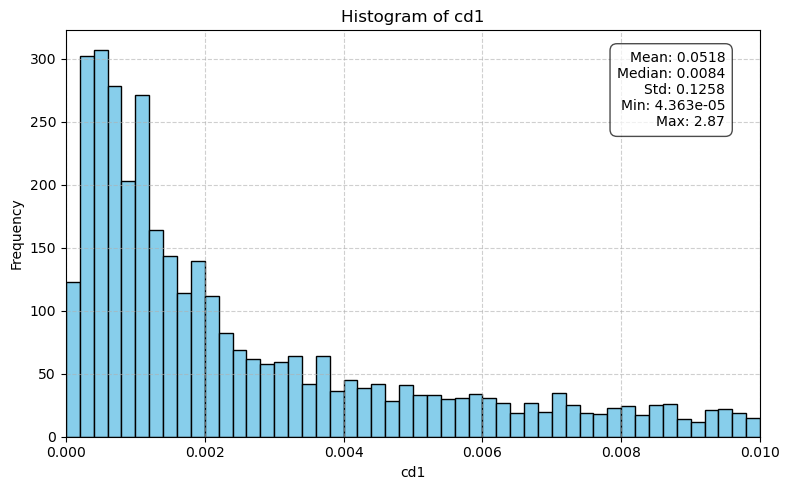

In [97]:
plot_histogram(df, 'cd1', xlim=(0, maxlim))

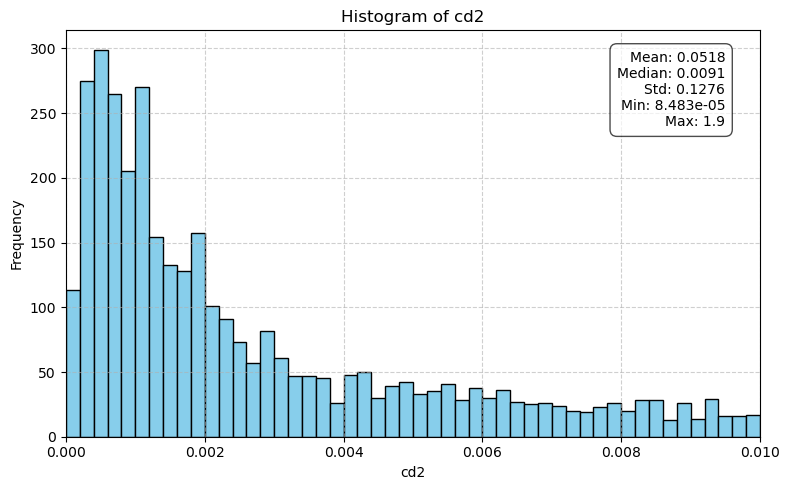

In [98]:
plot_histogram(df, 'cd2', xlim=(0, maxlim))

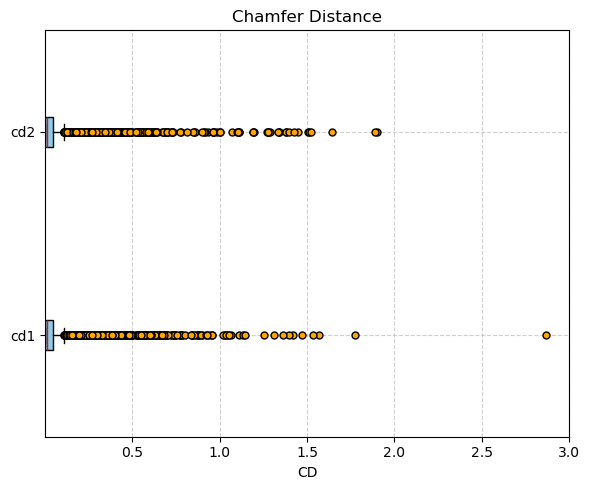

In [95]:
plot_multiple_boxplots(df, ['cd1', 'cd2'], xlim=(1e-5, 3), log_scale=False)

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(df, column_name, bins=50, xlim=(0, 3), save_path="dgr.png", dpi=300):
    """Plot histogram of a given column, ignoring NaNs. Optionally save the figure."""
    data = df[column_name].dropna()

    mean = np.nanmean(data)
    median = np.nanmedian(data)
    std = np.nanstd(data)
    max_val = np.nanmax(data)
    min_val = np.nanmin(data)

    # Calculate bin edges manually
    bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=bin_edges, color='skyblue', edgecolor='black')
    plt.xlim(xlim)  # Fixed x-axis
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')

    # Annotate with stats
    textstr = '\n'.join((
        f'Mean: {mean:.4f}',
        f'Median: {median:.4f}',
        f'Std: {std:.4f}',
        f'Min: {min_val:.4g}',
        f'Max: {max_val:.4g}'
    ))

    plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    
    plt.show()


def plot_boxplot(df, column_name, xlim=(1e-5, 3), save_path="boxplot.png", dpi=300, log_scale=False):
    """Plot boxplot of a given column, ignoring NaNs. If log_scale=True, transform data to log10."""
    data = df[column_name].dropna()

    if log_scale:
        # Remove non-positive entries, log not defined for 0 or negative
        data = data[data > 0]
        log_data = np.log10(data)
    else:
        log_data = data

    mean = np.nanmean(data)
    median = np.nanmedian(data)
    std = np.nanstd(data)
    max_val = np.nanmax(data)
    min_val = np.nanmin(data)

    plt.figure(figsize=(6, 5))
    plt.boxplot(log_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor='skyblue', color='black'),
                medianprops=dict(color='red'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(markerfacecolor='orange', marker='o', markersize=5, linestyle='none'))

    if log_scale:
        # Custom x-axis ticks for log10
        log_min, log_max = np.log10(xlim[0]), np.log10(xlim[1])
        ticks = np.linspace(log_min, log_max, num=6)
        tick_labels = [f"{10**t:.1e}" for t in ticks]

        plt.xticks(ticks, tick_labels)
        plt.xlim(log_min, log_max)
        plt.xlabel(f'{column_name} (log scale)')
    else:
        plt.xlim(xlim)
        plt.xlabel(column_name)

    plt.title(f'Boxplot of {column_name}')

    # Annotate stats
    textstr = '\n'.join((
        f'Mean: {mean:.4f}',
        f'Median: {median:.4f}',
        f'Std: {std:.4f}',
        f'Min: {min_val:.4g}',
        f'Max: {max_val:.4g}'
    ))

    plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

    plt.grid(True, linestyle='--', alpha=0.6, which='both')
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


def plot_multiple_boxplots(df, column_names, xlim=(1e-4, 3), save_path="mult_box.png", dpi=300, log_scale=False):
    """Plot multiple boxplots side-by-side for given columns, ignoring NaNs. Optionally use log scale and save."""
    
    # Prepare data: list of each column's non-NaN values
    data = [df[col].dropna() for col in column_names]

    # If log_scale is True, transform data to log10 scale
    if log_scale:
        # Only keep positive values
        data = [d[d > 0] for d in data]
        data = [np.log10(d) for d in data]

    # Calculate stats for each column
    stats = []
    for d in data:
        stats.append({
            'mean': np.nanmean(d),
            'median': np.nanmedian(d),
            'std': np.nanstd(d),
            'min': np.nanmin(d),
            'max': np.nanmax(d),
        })

    # Set up the figure size dynamically based on number of columns
    plt.figure(figsize=(max(6, len(column_names) * 2), 5))

    # Create boxplots
    box = plt.boxplot(data, vert=False, patch_artist=True,
                      boxprops=dict(facecolor='skyblue', color='black'),
                      medianprops=dict(color='red'),
                      whiskerprops=dict(color='black'),
                      capprops=dict(color='black'),
                      flierprops=dict(markerfacecolor='orange', marker='o', markersize=5, linestyle='none'))

    # Set xlim for the plot
    if log_scale:
        # Custom x-axis ticks for log10 scale
        log_min, log_max = np.log10(xlim[0]), np.log10(xlim[1])
        ticks = np.linspace(log_min, log_max, num=6)
        tick_labels = [f"{10**t:.1e}" for t in ticks]

        plt.xticks(ticks, tick_labels)
        plt.xlim(log_min, log_max)
        plt.xlabel('CD')
    else:
        plt.xlim(xlim)
        plt.xlabel('CD')

    # Set y-axis to match the number of columns
    plt.yticks(ticks=np.arange(1, len(column_names) + 1), labels=column_names)
    plt.title('Chamfer Distance')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save the figure if a path is provided
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()




## Next

- see where the largest CD differences are
- for these samples look if arg and cad loss

Erkentniss:
- Avg loss für cmd und arg wird in pc2cad falsch berechnet. ich nehme das average von den batches (die jeweils das average beinhalten) - die samples im letzten batch haben dadurch verhältnismäßig viel gewicht, da das letzte batch nicht ganz voll ist
    - Lösung: In der loss funktion die losses addieren und nicht den default mean nehmen, und dann durch die Anzahl der samples teilen
    - Andererseits ist es glaube nicht sooo wichtig gerade, denn die anderen metrics sind ja korrekt, und der Loss ist nicht so aussagekräftig
 
Done
- create overview of model results

Created Files:
- model1_vs_model2.csv